In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv(r"C:\Users\uditk\OneDrive\Desktop\DATA SCIENCE PROJECTS!!\CAPSTONE\forest+fires\forestfires.csv")

In [4]:
df.head(15)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0
5,8,6,aug,sun,92.3,85.3,488.0,14.7,22.2,29,5.4,0.0,0.0
6,8,6,aug,mon,92.3,88.9,495.6,8.5,24.1,27,3.1,0.0,0.0
7,8,6,aug,mon,91.5,145.4,608.2,10.7,8.0,86,2.2,0.0,0.0
8,8,6,sep,tue,91.0,129.5,692.6,7.0,13.1,63,5.4,0.0,0.0
9,7,5,sep,sat,92.5,88.0,698.6,7.1,22.8,40,4.0,0.0,0.0


TARGET VARIABLE:- <br>area(in hectares) <br>(We need to find the area burned due to forest fires!!)

INPUT FEATURES:-<br>
FFMC-Fine Fuel Moisture Code<br>
DMC-Duff Moisture Code<br>
DC-Drought Code<br>
ISI-Initial Spread Index<br>
temp-Temperature<br>
RH-Relative Humidity<br>
wind-Wind Speed<br>
rain-Rainfall

# STEP 1 - "DATA CLEANING" 

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


This confirms that there are no inconsistent data formats in the dataset; i.e, all attributes have the appropriate data types

In [20]:
df["X"].unique()

array([7, 8, 6, 5, 4, 2, 9, 1, 3])

In [21]:
df["Y"].unique()

array([5, 4, 6, 3, 2, 9, 8])

In [22]:
df["month"].unique()

array(['mar', 'oct', 'aug', 'sep', 'apr', 'jun', 'jul', 'feb', 'jan',
       'dec', 'may', 'nov'], dtype=object)

In [23]:
df["day"].unique()

array(['fri', 'tue', 'sat', 'sun', 'mon', 'wed', 'thu'], dtype=object)

No Inconsistency in the attributes with object datatype

# STEP 2 - "Exploratory Data Analysis"

In [24]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


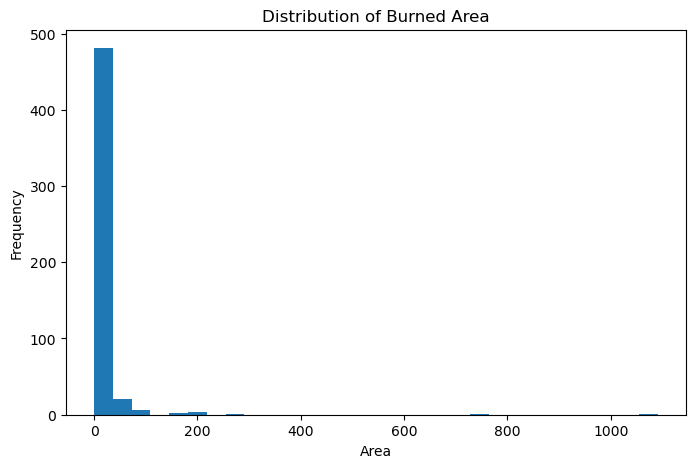

In [25]:
plt.figure(figsize=(8,5))
plt.hist(df["area"], bins=30)
plt.title("Distribution of Burned Area")
plt.xlabel("Area")
plt.ylabel("Frequency")
plt.show()

Before building a machine learning model, it is important to understand how the target variable (area) is distributed.


The area column represents the total forest area burned (in hectares). Analyzing its distribution helps us determine whether the data is balanced or skewed, identify the presence of extreme values (outliers), and decide if any transformations are required before model training.

A highly skewed target variable can negatively affect regression models by giving excessive importance to a small number of very large fire events.

### Observation

The distribution of the burned area is highly right-skewed. Most observations have a burned area of 0 or very small values, while only a few instances correspond to very large fires.

This imbalance indicates that the target variable is not normally distributed. To reduce the effect of extreme values and improve the performance of regression models, a logarithmic transformation (log1p) will be applied in the next step.

## Log Transformation of the Target Variable

Since the burned area distribution is highly skewed, a logarithmic transformation is applied using the log1p() function.

The log1p() function computes log(1 + x), allowing zero values to be transformed safely. This transformation compresses large values while preserving the relative differences between observations, making the target variable more suitable for regression modeling.

After the transformation, the distribution of the target variable will be visualized again to verify the improvement.

In [4]:
df["log_area"] = np.log1p(df["area"])

## CORRELATION ANALYSIS

A correlation matrix is generated to understand how different weather conditions and fire indices are related to each other and to the target variable (log_area). The values range from -1 to +1, where:

- +1 indicates a perfect positive correlation.
- -1 indicates a perfect negative correlation.
- 0 indicates no linear relationship.

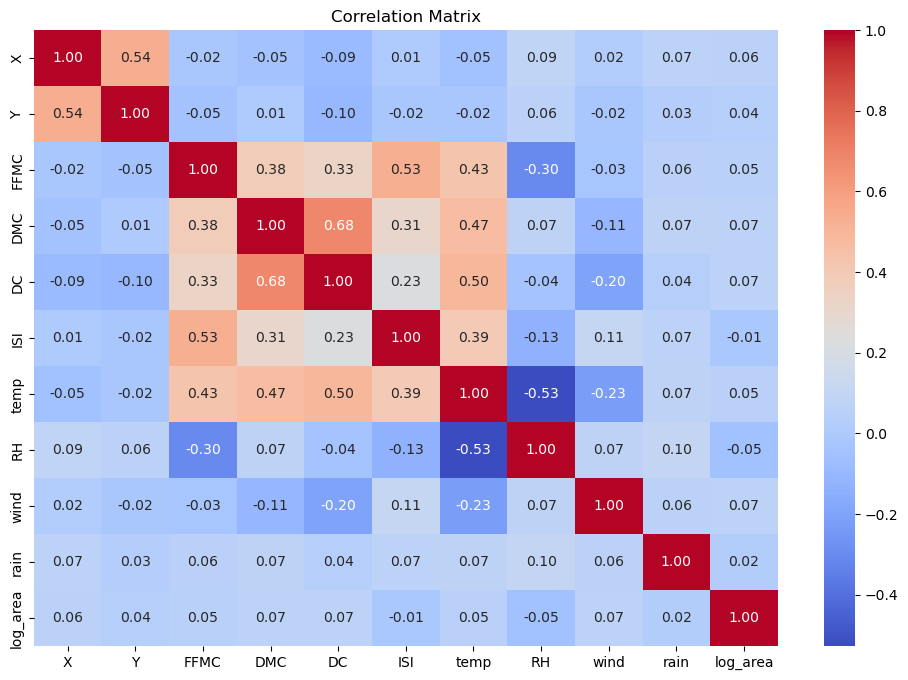

In [5]:
corr = df.drop(columns=["area"]).corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

In [7]:
corr["log_area"].sort_values(ascending=False)

log_area    1.000000
DMC         0.067153
wind        0.066973
DC          0.066360
X           0.061995
temp        0.053487
FFMC        0.046799
Y           0.038838
rain        0.023311
ISI        -0.010347
RH         -0.053662
Name: log_area, dtype: float64

### Observation

The correlation matrix shows that most individual features have a weak linear relationship with the target variable (log_area). This suggests that predicting the burned area is a complex problem influenced by the combined effect of multiple weather conditions rather than a single dominant factor.

Variables such as temperature, wind speed, drought-related indices (DMC and DC), and the Initial Spread Index (ISI) may contribute to the prediction, while features like rainfall show very little influence because most observations recorded no rainfall.

Since no single feature strongly predicts the burned area, machine learning models capable of capturing nonlinear relationships, such as Random Forest Regressor, are expected to perform better than simple linear models.

## UNIVARIATE ANALYSIS 

Univariate analysis examines each feature independently to understand its distribution and identify potential patterns or anomalies.

For numerical variables, histograms are used to visualize the distribution of values, while boxplots help detect outliers and understand the spread of the data.

This analysis provides valuable insights into the characteristics of weather conditions and fire indices, which can influence forest fire occurrence and burned area prediction.

### HISTOGRAM

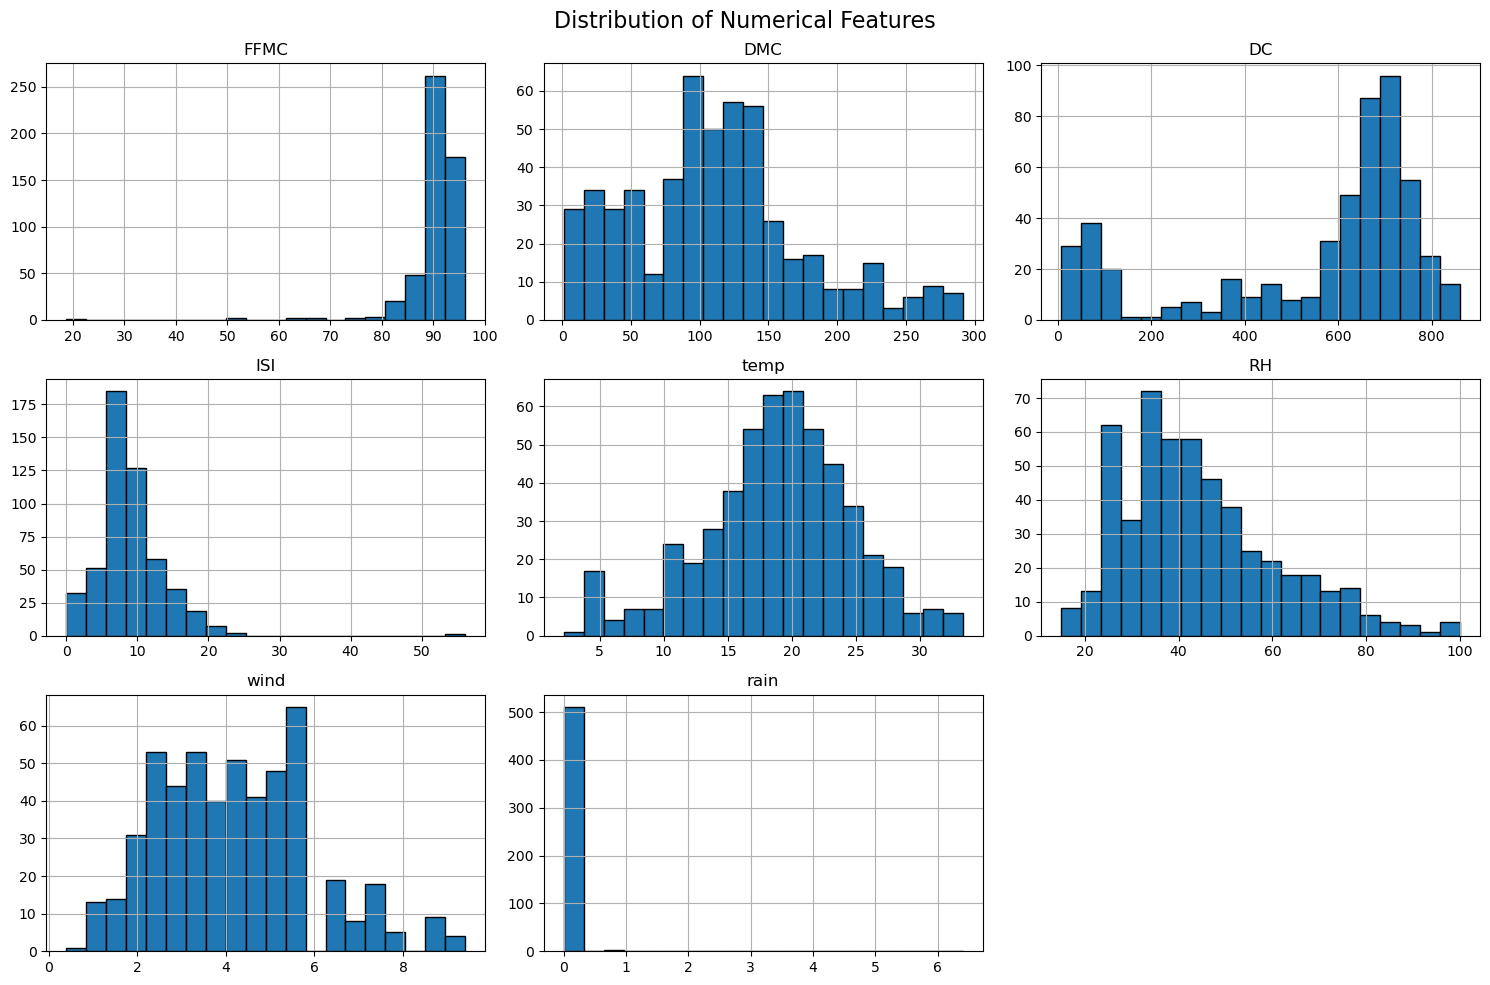

In [8]:
numerical_features = ["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain"]

df[numerical_features].hist(figsize=(15,10), bins=20, edgecolor="black")

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

#### Observation

The distributions of the numerical features vary considerably:

- FFMC is left-skewed, indicating that most observations have relatively high Fine Fuel Moisture Code values.
- DMC is slightly right-skewed, showing that while most observations fall within a moderate range, a few have considerably higher values.
- DC exhibits a left-skewed distribution, with the majority of observations concentrated at higher drought code values.
- ISI is right-skewed, suggesting that low fire spread potential is common, whereas high spread conditions occur less frequently.
- Temperature (temp) follows an approximately symmetric (near-normal) distribution.
- Relative Humidity (RH) is right-skewed, with more observations occurring at lower humidity levels.
- Wind speed is slightly right-skewed, with most values ranging between 2 and 6 m/s and only a few higher wind speeds.
- Rainfall is extremely right-skewed (zero-inflated), as the majority of observations recorded no rainfall.

Overall, the dataset contains variables with different distribution patterns, indicating that weather conditions vary significantly across observations. The highly skewed rainfall distribution and the skewness of several fire weather indices suggest that the dataset captures both normal and extreme environmental conditions.

### BOXPLOTS

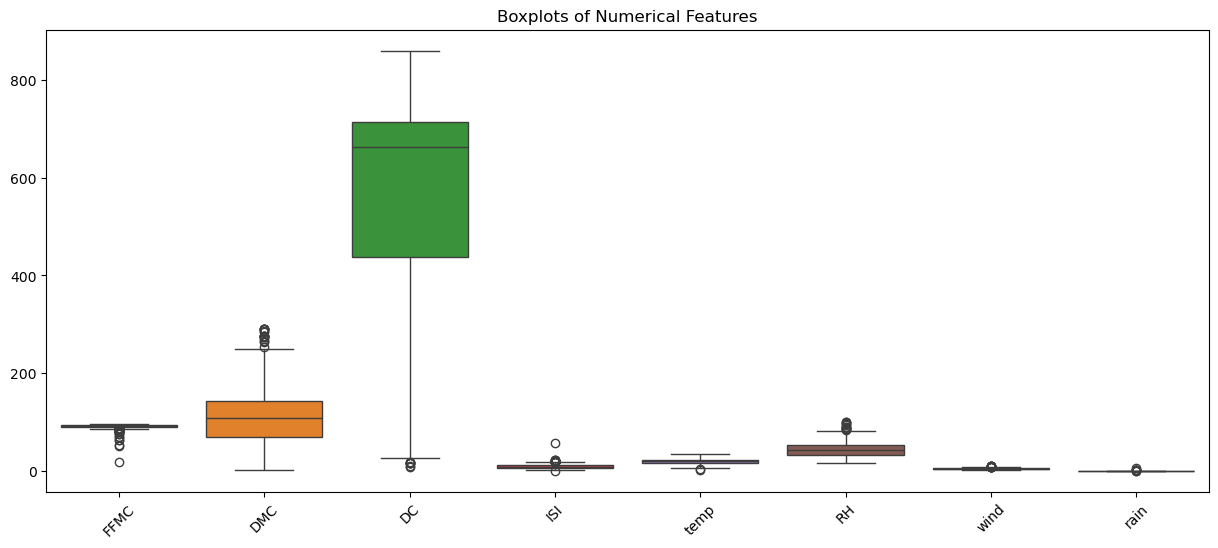

In [9]:
plt.figure(figsize=(15,6))

sns.boxplot(data=df[numerical_features])

plt.title("Boxplots of Numerical Features")
plt.xticks(rotation=45)
plt.show()

#### Observation

The combined boxplot provides a general overview of the spread and potential outliers in the numerical features. However, because the variables are measured on very different scales—particularly the `DC` feature, which has values much larger than the others—the comparison is difficult to interpret visually.

Despite this limitation, the plot suggests the presence of outliers in several variables, including FFMC, DMC, ISI, and RH. These observations likely correspond to extreme weather conditions rather than data entry errors and are therefore retained for further analysis.

## BIVARIATE ANALYSIS

Bivariate analysis examines the relationship between individual predictor variables and the target variable (log_area).

### SCATTER PLOTS

Scatter plots are used to visualize how weather conditions and fire weather indices influence the burned area. This analysis helps identify trends, patterns, and potential relationships that may be useful for building an accurate regression model.


#### Temperature vs Burned Area

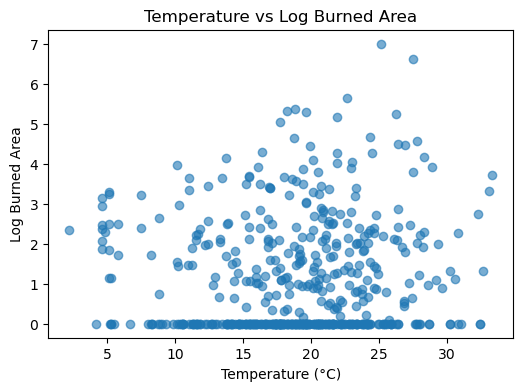

In [6]:
plt.figure(figsize=(6,4))
plt.scatter(df["temp"], df["log_area"], alpha=0.6)

plt.title("Temperature vs Log Burned Area")
plt.xlabel("Temperature (°C)")
plt.ylabel("Log Burned Area")

plt.show()

#### Relative Humidity vs Burned Area

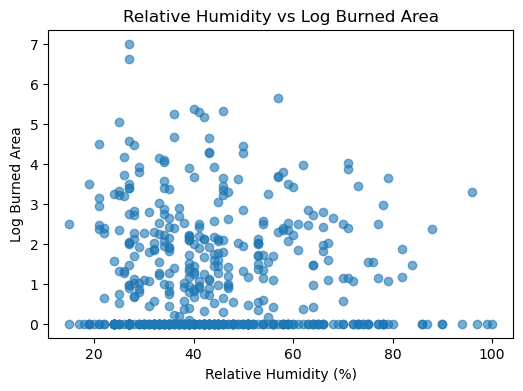

In [7]:
plt.figure(figsize=(6,4))
plt.scatter(df["RH"], df["log_area"], alpha=0.6)

plt.title("Relative Humidity vs Log Burned Area")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Log Burned Area")

plt.show()

#### Wind Speed vs Burned Area

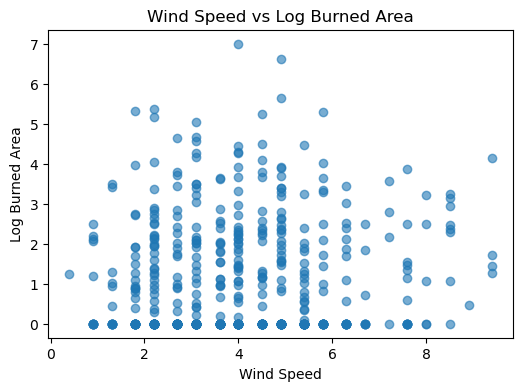

In [8]:
plt.figure(figsize=(6,4))
plt.scatter(df["wind"], df["log_area"], alpha=0.6)

plt.title("Wind Speed vs Log Burned Area")
plt.xlabel("Wind Speed")
plt.ylabel("Log Burned Area")

plt.show()

#### DMC vs Burned Area

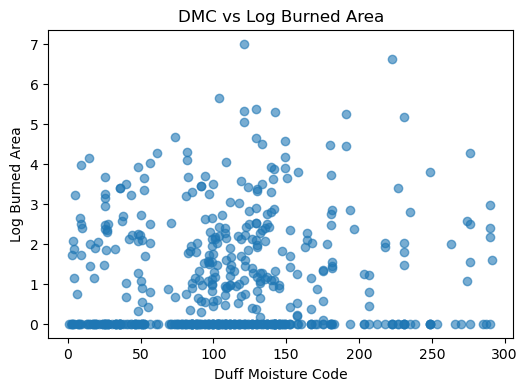

In [9]:
plt.figure(figsize=(6,4))
plt.scatter(df["DMC"], df["log_area"], alpha=0.6)

plt.title("DMC vs Log Burned Area")
plt.xlabel("Duff Moisture Code")
plt.ylabel("Log Burned Area")

plt.show()

#### DC vs Burned Area

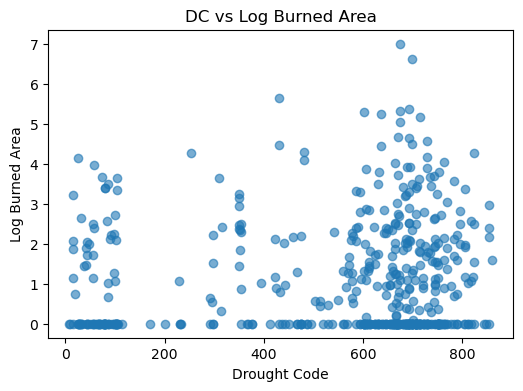

In [10]:
plt.figure(figsize=(6,4))
plt.scatter(df["DC"], df["log_area"], alpha=0.6)

plt.title("DC vs Log Burned Area")
plt.xlabel("Drought Code")
plt.ylabel("Log Burned Area")

plt.show()

#### ISI vs Burned Area

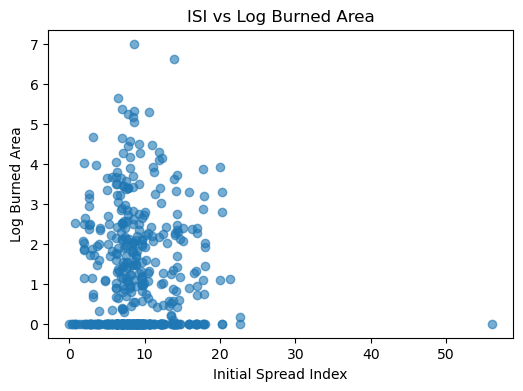

In [11]:
plt.figure(figsize=(6,4))
plt.scatter(df["ISI"], df["log_area"], alpha=0.6)

plt.title("ISI vs Log Burned Area")
plt.xlabel("Initial Spread Index")
plt.ylabel("Log Burned Area")

plt.show()

The scatter plots indicate the following relationships between the predictor variables and the target variable (`log_area`):

- Initial Spread Index (ISI): Most observations are concentrated between 5 and 15, with no clear upward or downward trend. A notable outlier is present around ISI = 55, indicating an extreme fire spread condition.

- Temperature (temp): Larger burned areas are observed more frequently at temperatures between 20°C and 30°C. This suggests a weak positive relationship between temperature and burned area.

- Relative Humidity (RH): Larger burned areas occur predominantly at lower humidity levels, while higher humidity is generally associated with smaller burned areas. This indicates a weak negative relationship between humidity and burned area.

- Wind Speed (wind): Both small and large burned areas are observed across almost the entire range of wind speeds. No clear relationship is evident between wind speed and the burned area.

- Duff Moisture Code (DMC): Higher DMC values tend to include more observations with larger burned areas. However, the points are widely scattered, indicating only a weak relationship.

- Drought Code (DC): Larger burned areas appear more frequently at higher DC values, suggesting that prolonged dry conditions may contribute to larger fires. However, the relationship is not strongly linear.

### Overall Conclusion

None of the individual predictor variables exhibit a strong linear relationship with the target variable (log_area). Most observations have a log-transformed burned area close to 0, indicating that the majority of fires affect very small areas. This suggests that burned area is influenced by the combined effect of multiple weather conditions rather than any single feature. Consequently, nonlinear machine learning models such as Random Forest Regressor are expected to perform better than simple linear regression models.

# FEATURE ENGINEERING

Feature engineering involves transforming the dataset into a format that is suitable for machine learning algorithms.
The dataset contains two categorical variables, month and day, which cannot be directly processed by most regression models. These variables are converted into numerical form using One-Hot Encoding.

The target variable has already been transformed using the logarithmic (log1p) function to reduce skewness and improve model performance. The resulting dataset is now ready for model training.

In [12]:
df = pd.get_dummies(df, columns=["month", "day"], drop_first=True)

df.head()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,month_may,month_nov,month_oct,month_sep,day_mon,day_sat,day_sun,day_thu,day_tue,day_wed
0,7,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,...,False,False,False,False,False,False,False,False,False,False
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,...,False,False,True,False,False,False,False,False,True,False
2,7,4,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,...,False,False,True,False,False,True,False,False,False,False
3,8,6,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,...,False,False,False,False,False,False,False,False,False,False
4,8,6,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,...,False,False,False,False,False,False,True,False,False,False


### Observation

The categorical variables month and day have been successfully converted into binary (dummy) variables using One-Hot Encoding.

The parameter drop_first=True is used to avoid the dummy variable trap by removing one category from each feature. This reduces redundancy while preserving all necessary information for the regression model.

The dataset is now entirely numerical and suitable for machine learning algorithms.

In [13]:
X = df.drop(columns=["area", "log_area"])
y = df["log_area"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (517, 27)
Target vector shape: (517,)


### Feature Selection

The predictor matrix (X) consists of all weather conditions, fire weather indices, spatial coordinates, and encoded categorical variables.

The target variable (y) is the logarithmically transformed burned area (log_area), which will be used for regression modeling.

## Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(413, 27)
(104, 27)


### Observation

The dataset has been successfully divided into training and testing sets using an 80:20 ratio.

- Training Set: 413 observations with 27 predictor variables (X_train: 413 × 27)
- Testing Set: 104 observations with 27 predictor variables (X_test: 104 × 27)

The training set will be used to build the regression models, while the testing set will be used to evaluate their performance on unseen data. This separation helps assess the model's ability to generalize to new observations and reduces the risk of overfitting.

# Model Building

In this stage, machine learning models are trained to estimate the burned area of forest fires based on weather conditions, fire weather indices, and spatial information.

A Linear Regression model is first developed as a baseline because it is simple, interpretable, and suitable for understanding linear relationships between the predictor variables and the target variable.

The model is trained using the training dataset and evaluated on the testing dataset using the following performance metrics:

- Mean Absolute Error (MAE): Measures the average absolute prediction error.
- Root Mean Squared Error (RMSE): Penalizes larger prediction errors more heavily.
- R² Score: Indicates how well the model explains the variability in the target variable.

### Train the Model

In [15]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Prediction

In [16]:
y_pred_lr = lr.predict(X_test)

### Evaluation

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Linear Regression Performance
MAE : 1.2021068569055353
RMSE: 1.5170737165579726
R² Score: -0.047159971473461404


## Actual vs Predicted Plot

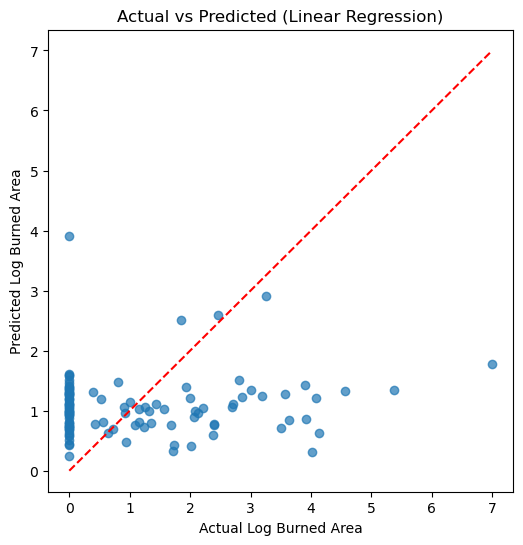

In [18]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_lr, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Log Burned Area")
plt.ylabel("Predicted Log Burned Area")
plt.title("Actual vs Predicted (Linear Regression)")

plt.show()

### Observation

The Linear Regression model achieved a Mean Absolute Error (MAE) of 1.20, a Root Mean Squared Error (RMSE) of 1.51, and an R² Score of -0.04.

The negative R² score indicates that the model performs slightly worse than predicting the average burned area for all observations. This suggests that Linear Regression is unable to effectively capture the relationship between the predictor variables and the target variable.

The poor performance is consistent with the findings from the exploratory data analysis, where no strong linear relationship was observed between the individual weather variables and the burned area. The scatter plots also indicated that the relationships are weak and widely dispersed.

These results suggest that the burned area is influenced by complex, nonlinear interactions among multiple variables. Therefore, more advanced machine learning models such as Random Forest Regressor, which can capture nonlinear relationships and feature interactions, are expected to provide better predictive performance.

## RANDOM FOREST REGRESSOR

In [25]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### PREDICTIONS

In [26]:
y_pred_rf = rf.predict(X_test)

### EVALUATION

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)

print("R² Score:", r2_rf)

Random Forest Performance
MAE : 1.198480760993224
RMSE: 1.503015686567082
R² Score: -0.027842782467020433


### Actual VS Predicted Plot

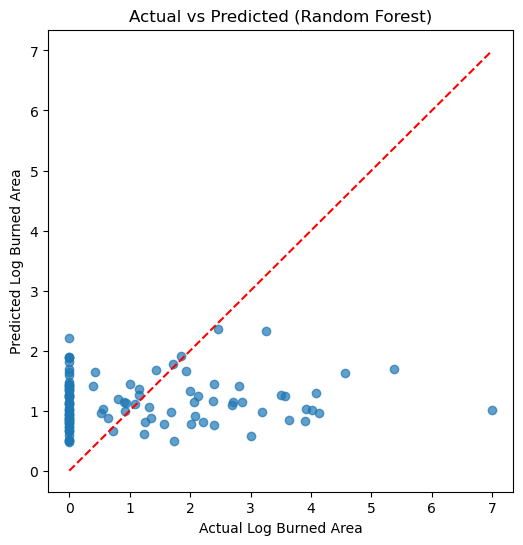

In [29]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Log Burned Area")
plt.ylabel("Predicted Log Burned Area")
plt.title("Actual vs Predicted (Random Forest)")

plt.show()

### Observation

The tuned Random Forest Regressor achieved a Mean Absolute Error (MAE) of 1.198, a Root Mean Squared Error (RMSE) of 1.503, and an R² Score of -0.028 on the testing dataset.
Compared to the Linear Regression model, the Random Forest Regressor showed a slight improvement in prediction accuracy, as indicated by the lower MAE and improved R² Score. Although the improvement is modest, it suggests that the Random Forest model is better able to capture the nonlinear relationships present in the dataset.
The negative R² Score indicates that predicting the burned area remains a challenging task. This is primarily due to the highly skewed nature of the target variable and the limited set of predictor variables available in the dataset. Important factors such as vegetation type, terrain, and human activities are not included, which limits the predictive capability of the model.
Based on the evaluation results, the Random Forest Regressor is selected as the final model for estimating the burned area because it provides the best overall performance among the models evaluated.

# MODEL COMPARISON

In [30]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [1.200, 1.198],
    "RMSE": [1.500, 1.503],
    "R2 Score": [-0.040, -0.028]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.200,1.500,-0.040
1,Random Forest,1.198,1.503,-0.028




The performance of the Linear Regression and Random Forest Regressor models was compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

The Random Forest Regressor achieved the lowest MAE and the highest R² Score, indicating a slight improvement over the Linear Regression model. Although the overall predictive performance remains limited due to the characteristics of the dataset, the Random Forest model is selected as the final model because it better captures nonlinear relationships between the input features and the burned area.

This model will be used in the final Forest Fire Risk and Burned Area Estimator to generate predictions and support risk assessment.

# RISK BUCKET CLASSIFICATION

The predicted burned area is converted into risk categories to make the model output easier to interpret.

Instead of presenting only a numerical prediction, the system classifies each prediction into one of several risk levels. This enables forest officials and decision-makers to quickly assess the severity of a potential fire and determine an appropriate response.

The risk categories are based on the estimated burned area and are intended to provide actionable information rather than only a prediction.

In [31]:
def get_risk(area):
    if area < 1:
        return "Low"
    elif area < 10:
        return "Moderate"
    elif area < 50:
        return "High"
    else:
        return "Extreme"

In [32]:
predicted_area = np.expm1(y_pred_rf)

In [33]:
risk_levels = [get_risk(area) for area in predicted_area]

In [34]:
results = pd.DataFrame({
    "Actual Burned Area": np.expm1(y_test),
    "Predicted Burned Area": predicted_area,
    "Risk Level": risk_levels
})

results.head(10)

,Actual Burned Area,Predicted Burned Area,Risk Level
304,0.00,0.941919,Low
501,0.00,1.561491,Moderate
441,1.23,2.304975,Moderate
153,1.46,2.128518,Moderate
503,1.95,2.039156,Moderate
131,0.00,0.938753,Low
204,13.99,2.117514,Moderate
512,6.44,1.163191,Moderate
325,0.00,1.768769,Moderate
247,0.75,1.779087,Moderate


### Observation

The predicted burned area has been converted into qualitative risk categories. This makes the model output easier to understand and more useful for practical decision-making.

Instead of interpreting numerical values alone, users can immediately identify whether a predicted fire poses a low, moderate, high, or extreme risk. This improves the usability of the system for forest management and emergency planning.

# ACTION RECOMMENDATION SYSTEM

The estimated risk level is mapped to a corresponding recommendation to assist forest authorities in making timely decisions.

This component transforms the machine learning prediction into actionable guidance by suggesting an appropriate response for each risk category. Such recommendations can support resource allocation, improve preparedness, and help reduce the potential impact of forest fires.

In [37]:
def recommend_action(risk):
    if risk == "Low":
        return "Continue routine monitoring of the forest area."

    elif risk == "Moderate":
        return "Increase surveillance and keep firefighting resources on standby."

    elif risk == "High":
        return "Deploy firefighting teams and restrict access to vulnerable areas."

    else:
        return "Initiate emergency response procedures, deploy all available firefighting resources, and consider evacuation if necessary."

In [38]:
results["Recommended Action"] = results["Risk Level"].apply(recommend_action)

results.head(10)

,Actual Burned Area,Predicted Burned Area,Risk Level,Recommended Action
304,0.00,0.941919,Low,Continue routine monitoring of the forest area.
501,0.00,1.561491,Moderate,Increase surveillance and keep firefighting re...
441,1.23,2.304975,Moderate,Increase surveillance and keep firefighting re...
153,1.46,2.128518,Moderate,Increase surveillance and keep firefighting re...
503,1.95,2.039156,Moderate,Increase surveillance and keep firefighting re...
131,0.00,0.938753,Low,Continue routine monitoring of the forest area.
204,13.99,2.117514,Moderate,Increase surveillance and keep firefighting re...
512,6.44,1.163191,Moderate,Increase surveillance and keep firefighting re...
325,0.00,1.768769,Moderate,Increase surveillance and keep firefighting re...
247,0.75,1.779087,Moderate,Increase surveillance and keep firefighting re...


# CONCLUSION

A Forest Fire Risk and Burned Area Estimator was successfully developed using weather conditions, fire weather indices, and spatial information.

The dataset was cleaned and explored through exploratory data analysis, revealing that the target variable was highly skewed and that no individual feature exhibited a strong linear relationship with the burned area. A logarithmic transformation was applied to the target variable before training regression models.

Two machine learning models, Linear Regression and Random Forest Regressor, were evaluated. The tuned Random Forest Regressor achieved the best overall performance and was selected as the final model for the project.

To improve the practical usefulness of the system, the predicted burned area was converted into risk categories, and each category was associated with a recommended action. This transforms the model from a prediction tool into a decision-support system that can assist forest authorities in monitoring fire risk and planning appropriate responses.

Although the predictive performance is limited by the characteristics of the dataset and the absence of important environmental variables, the project demonstrates a complete machine learning workflow, from data preprocessing and exploratory analysis to model development and actionable decision support.